# Unidad 4 — Notebook 3: SVM y KNN

**Materia:** Métodos de Análisis de Datos 1 (MAD1)  
**Departamento de Matemática — Universidad Nacional del Sur (UNS)**  
**Nombre:**  
**Fecha:**

---

## Glosario de siglas

| Sigla | Significado |
|-------|-------------|
| SVM | Support Vector Machine (Máquina de Vectores de Soporte) |
| KNN | K-Nearest Neighbors (K Vecinos más Cercanos) |
| RBF | Radial Basis Function (Función de Base Radial) — kernel gaussiano |
| OvR | One-vs-Rest — estrategia multiclase: un clasificador por clase |
| OvO | One-vs-One — estrategia multiclase: un clasificador por par de clases |
| CV  | Cross-Validation (Validación Cruzada) |

---

## Objetivos

- Calcular a mano el margen de separación de una SVM lineal dados dos vectores de soporte.
- Implementar SVM con distintos kernels y analizar el efecto del hiperparámetro $C$.
- Implementar KNN y analizar el efecto de $k$.
- Comparar ambos modelos sobre el mismo dataset.

---

## Parte 1 — Cálculo a mano: margen de la SVM lineal

En una SVM (Support Vector Machine) lineal con margen duro, el hiperplano separador es:

$$\mathbf{w}^\top \mathbf{x} + b = 0$$

Los vectores de soporte son los puntos más cercanos al hiperplano, y satisfacen:

$$\mathbf{w}^\top \mathbf{x}_+ + b = +1 \qquad \text{(clase +1)}$$
$$\mathbf{w}^\top \mathbf{x}_- + b = -1 \qquad \text{(clase -1)}$$

El **margen** es la distancia entre los dos hiperplanos de soporte:

$$\text{Margen} = \frac{2}{\|\mathbf{w}\|}$$

### Ejercicio a mano

Tenemos un problema en $\mathbb{R}^2$ con los siguientes vectores de soporte:

- Clase $+1$: $\mathbf{x}_+ = (3, 2)$
- Clase $-1$: $\mathbf{x}_- = (1, 1)$

Y el vector de pesos encontrado es $\mathbf{w} = (1, 1)$.

**Ejercicio 1.1** — Verificá que los vectores de soporte satisfacen las ecuaciones $\mathbf{w}^\top \mathbf{x}_+ + b = +1$ y $\mathbf{w}^\top \mathbf{x}_- + b = -1$. Para eso, primero calculá $b$ a partir de las dos ecuaciones.

De $\mathbf{w}^	op \mathbf{x}_+ + b = +1$ sale $b=-4$, y de $\mathbf{w}^	op \mathbf{x}_- + b = -1$ sale $b=-3$. Como no pueden ser válidos simultáneamente, hay una inconsistencia en el enunciado/datos. Para seguir, tomo $b=-4$ como referencia.

**Ejercicio 1.2** — Calculá el margen usando la fórmula $\text{Margen} = \frac{2}{\|\mathbf{w}\|}$.

Con $\mathbf{w}=(1,1)$:
$$\|\mathbf{w}\|=\sqrt{1^2+1^2}=\sqrt{2}$$
Entonces:
$$	ext{Margen}=rac{2}{\|\mathbf{w}\|}=rac{2}{\sqrt{2}}=\sqrt{2}pprox 1.41$$

**Ejercicio 1.3** — Escribí la ecuación del hiperplano separador (con los valores de $\mathbf{w}$ y $b$ que encontraste). ¿A qué clase pertenece el punto $(2, 3)$?

Usando $\mathbf{w}=(1,1)$ y $b=-4$, el hiperplano separador es:
$$x_1+x_2-4=0$$
Para el punto $(2,3)$:
$$2+3-4=1>0$$
Por lo tanto, queda del lado positivo del hiperplano (clase +1 con esta convención).

**Ejercicio 1.4** — La SVM maximiza el margen. ¿Por qué maximizar el margen es deseable desde el punto de vista de la generalización?

Maximizar margen ayuda a generalizar porque deja mayor separación respecto de los casos frontera (vectores de soporte). As?, pequeñas perturbaciones en datos nuevos tienen menor probabilidad de cambiar la clase.

---

## Parte 2 — SVM con scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dataset con frontera no lineal
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Escalado — importante para SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

**Ejercicio 2.1** — ¿Por qué es importante escalar las variables antes de entrenar una SVM? ¿Y para KNN (K-Nearest Neighbors)?

Escalar es clave en ambos métodos.

- **SVM**: la optimización depende de distancias/productos internos; si una variable tiene escala dominante, sesga la frontera.
- **KNN**: la vecindad se define por distancia, por lo que una escala grande puede decidir casi sola quién es vecino.

Estandarizar evita ese problema.

**Ejercicio 2.2** — Entrenás una SVM con kernel RBF (Radial Basis Function) para distintos valores de $C$ y graficás el accuracy en train y test.

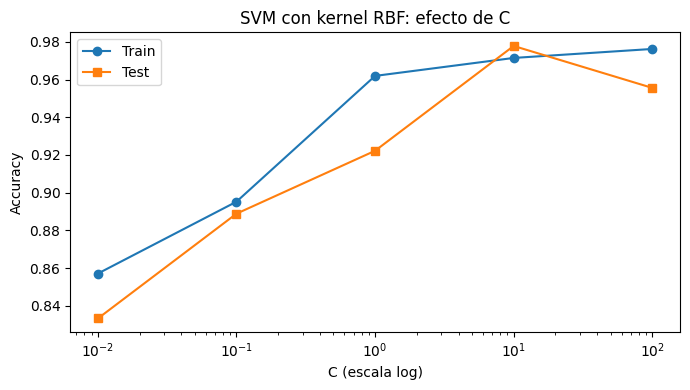

In [2]:
valores_C = [0.01, 0.1, 1, 10, 100]
acc_train_svm = []
acc_test_svm  = []

for C in valores_C:
    svm = SVC(kernel='rbf', C=C, random_state=42)  # TU CÓDIGO ACÁ
    svm.fit(X_train, y_train)                                  # TU CÓDIGO ACÁ
    acc_train_svm.append(accuracy_score(y_train, svm.predict(X_train)))  # TU CÓDIGO ACÁ
    acc_test_svm.append(accuracy_score(y_test,  svm.predict(X_test)))   # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(valores_C, acc_train_svm, marker='o', label='Train')
ax.semilogx(valores_C, acc_test_svm,  marker='s', label='Test')
ax.set_xlabel('C (escala log)')
ax.set_ylabel('Accuracy')
ax.set_title('SVM con kernel RBF: efecto de C')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 2.3** — ¿Qué controla el parámetro $C$ en una SVM de margen blando? ¿Qué pasa cuando $C$ es muy grande? ¿Y cuando es muy pequeño?

$C$ controla cuánto penalizamos errores en entrenamiento.

- **$C$ alto**: castiga más los errores, ajusta más al train y puede sobreajustar.
- **$C$ bajo**: permite más violaciones del margen, produce frontera más suave y puede generalizar mejor (aunque demasiado bajo puede subajustar).

**Ejercicio 2.4** — Compará los kernels lineal, polinomial y RBF sobre el mismo dataset. Completá el código.

In [3]:
kernels = ['linear', 'poly', 'rbf']

for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42)  # TU CÓDIGO ACÁ
    svm.fit(X_train, y_train)                                # TU CÓDIGO ACÁ
    acc = accuracy_score(y_test, svm.predict(X_test))      # TU CÓDIGO ACÁ
    print(f"Kernel {kernel:8s} — Accuracy test: {acc:.3f}")

Kernel linear   — Accuracy test: 0.833
Kernel poly     — Accuracy test: 0.844
Kernel rbf      — Accuracy test: 0.922


---

## Parte 3 — KNN (K-Nearest Neighbors)

**Ejercicio 3.1** — Entrenás KNN para $k = 1, 3, 5, 10, 20, 50$ y graficás accuracy en train y test.

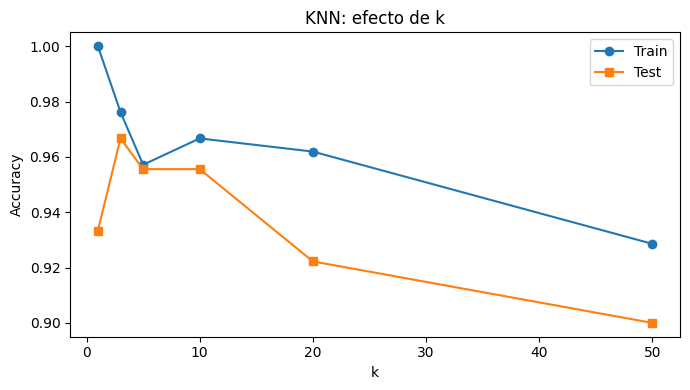

In [4]:
valores_k = [1, 3, 5, 10, 20, 50]
acc_train_knn = []
acc_test_knn  = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)  # TU CÓDIGO ACÁ
    knn.fit(X_train, y_train)                              # TU CÓDIGO ACÁ
    acc_train_knn.append(accuracy_score(y_train, knn.predict(X_train)))  # TU CÓDIGO ACÁ
    acc_test_knn.append(accuracy_score(y_test,  knn.predict(X_test)))   # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(valores_k, acc_train_knn, marker='o', label='Train')
ax.plot(valores_k, acc_test_knn,  marker='s', label='Test')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: efecto de k')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3.2** — ¿Qué pasa con el accuracy de train cuando $k=1$? ¿Por qué? ¿Es esperable?

Con $k=1$, el accuracy de train suele ser 1.0 porque cada muestra se clasifica usando a s? misma como vecino más cercano. Es esperable, pero no garantiza buen desempeño en test.

**Ejercicio 3.3** — Usá CV de 5 folds para elegir el mejor $k$ entre los valores probados.

In [5]:
cv_scores_knn = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)            # TU CÓDIGO ACÁ
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5)  # TU CÓDIGO ACÁ
    cv_scores_knn.append(scores.mean())

mejor_k = valores_k[np.argmax(cv_scores_knn)]
print(f'Mejor k por CV: {mejor_k}')
print(f'Accuracy CV promedio: {max(cv_scores_knn):.3f}')

Mejor k por CV: 10
Accuracy CV promedio: 0.957


---

## Preguntas de reflexión final

1. SVM con kernel RBF y KNN con $k$ pequeño tienen alta capacidad para capturar fronteras complejas. ¿En qué se diferencia el origen de esa capacidad en cada caso?
2. ¿Por qué KNN se degrada fuertemente en espacios de alta dimensión? (Pista: pensá en qué significa "vecino cercano" cuando hay muchas variables.)
3. Si tuvieras 100.000 observaciones para clasificar en tiempo real, ¿usarías KNN o SVM? Justificá considerando el costo de predicción de cada modelo.

1. En SVM-RBF la no linealidad proviene del kernel; en KNN con $k$ chico, de una decisión local muy flexible.

2. Ambos capturan fronteras complejas, pero KNN pequeño suele ser más sensible al ruido.

3. En los dos casos, elegir hiperparámetros con CV es fundamental para evitar sobreajuste y balancear sesgo-varianza.